# Lab 4: 文生图 — Z-Image-Turbo + OpenVINO

Z-Image-Turbo 是阿里巴巴开源的 6B 参数图像生成模型，属于 Z-Image 系列。它基于可扩展的单流 DiT（S3-DiT）架构，支持高质量文生图，同时具备优秀的中英双语文字渲染能力。

**主要特点:**
- 📸 照片级真实感图像生成
- 🀄 强大的中英双语文字渲染能力
- 🎨 优秀的指令遵循和上下文编辑能力
- ⚡ 支持 1-8 步高质量生成

在本实验中，我们将：
1. 从 ModelScope 下载预转换的 OpenVINO 模型
2. 使用 OpenVINO 加载并运行文生图推理
3. 体验交互式 Gradio 文生图演示

#### 目录：
- [下载模型](#下载模型)
- [选择推理设备](#选择推理设备)
- [加载模型](#加载模型)
- [运行文生图](#运行文生图)
- [交互式演示](#交互式演示)

## 下载模型
[返回目录 ⬆️](#目录：)

从 ModelScope 下载已转换并量化好的 Z-Image-Turbo OpenVINO INT4 模型。如果模型已存在则跳过下载。

In [1]:
from pathlib import Path

model_dir = Path("Z-Image-Turbo-int4-ov")

if not model_dir.exists():
    from modelscope import snapshot_download
    snapshot_download("snake7gun/Z-Image-Turbo-int4-ov", local_dir=str(model_dir))
    print(f"模型已下载到: {model_dir}")
else:
    print(f"模型已存在: {model_dir}，跳过下载")

模型已存在: Z-Image-Turbo-int4-ov，跳过下载


## 选择推理设备
[返回目录 ⬆️](#目录：)

选择用于推理的设备。CPU 兼容性最好，GPU 可在支持的硬件上提供加速。

In [2]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

## 加载模型
[返回目录 ⬆️](#目录：)

使用 Optimum Intel 的 `OVZImagePipeline` 加载 OpenVINO 模型。该接口与 Diffusers 的 Pipeline 实现兼容。

In [3]:
from optimum.intel import OVZImagePipeline

ov_pipe = OVZImagePipeline.from_pretrained(model_dir, device=device.value)
print("✅ 模型加载完成")

Multiple distributions found for package optimum. Picked distribution: optimum
D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


✅ 模型加载完成


## 运行文生图
[返回目录 ⬆️](#目录：)

让我们用一段提示词来生成图像。Z-Image-Turbo 支持中英双语提示词。

  0%|          | 0/9 [00:00<?, ?it/s]

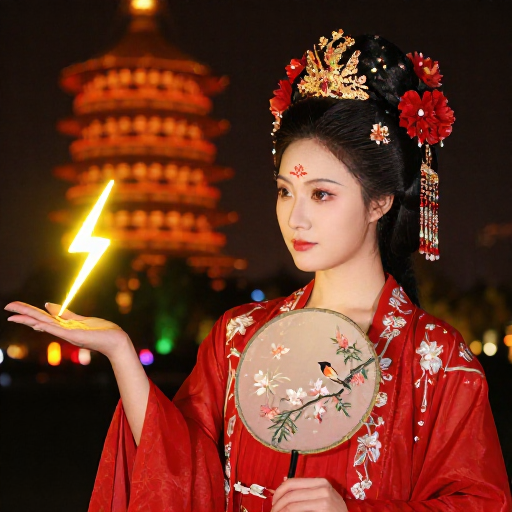

In [4]:
import torch

prompt = "Young Chinese woman in red Hanfu, intricate embroidery. Impeccable makeup, red floral forehead pattern. Elaborate high bun, golden phoenix headdress, red flowers, beads. Holds round folding fan with lady, trees, bird. Neon lightning-bolt lamp, bright yellow glow, above extended left palm. Soft-lit outdoor night background, silhouetted tiered pagoda, blurred colorful distant lights."

image = ov_pipe(
    prompt=prompt,
    height=512,
    width=512,
    num_inference_steps=9,
    guidance_scale=0.0,
    generator=torch.Generator("cpu").manual_seed(42),
).images[0]

image

## 交互式演示
[返回目录 ⬆️](#目录：)

启动 Gradio 交互式演示，你可以：
- 输入中文或英文提示词
- 选择不同的输出分辨率
- 调整推理步数和种子值
- 查看生成的图像

In [ ]:
from gradio_helper import make_demo

demo = make_demo(ov_pipe)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


  0%|          | 0/9 [00:00<?, ?steps/s]

Traceback (most recent call last):
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\blocks.py", line 2158, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\blocks.py", line 1634, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\an

  0%|          | 0/9 [00:00<?, ?steps/s]

Traceback (most recent call last):
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\blocks.py", line 2158, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\blocks.py", line 1634, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\an

  0%|          | 0/9 [00:00<?, ?steps/s]

Traceback (most recent call last):
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\blocks.py", line 2158, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\blocks.py", line 1634, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\an

  0%|          | 0/9 [00:00<?, ?steps/s]

Traceback (most recent call last):
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\blocks.py", line 2158, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\gradio\blocks.py", line 1634, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\ai-contest\modelscope-workshop\ov_workshop\Lib\site-packages\an